In [17]:
from model_ranking import (
    load_h5,
    find_dataset_object_sizes,
    get_evaluation_loaders,
    EvalDataloaderConfig,
    EvalDatasetConfig,
    get_random_colors
)
import numpy as np
import matplotlib.pyplot as plt

In [2]:
p_gt_path = "/scratch/talks/data/PNAS/test/24hrs_plant18_trim-acylYFP.h5"
label_key = "label"
raw_key = "raw"

p_gt = load_h5(p_gt_path, label_key)
p_raw = load_h5(p_gt_path, raw_key)
print(p_gt.shape, p_raw.shape)

(174, 512, 512) (174, 512, 512)


In [3]:
_, max_obj_size, obj_counts = find_dataset_object_sizes(
    p_gt, ignore_indexes=[1])
print("Max object size:", max_obj_size)

Max object size: 2173


In [9]:
unique, counts = np.unique(p_gt, return_counts=True)
print(unique)

[   1    2    3 ... 1134 1135 1136]


In [9]:
config = {
    "eval_dataloader": {
        "eval_dataset": {
            "name": "StandardEvalDataset",
            "aug_name": "predictions",
            "pred_path": ["/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_PNAS_gap/consistency/P_full/fw_model_Res2/norm_50_950/gauss_a01-02/predictions"],
            "gt_path": [
                "/scratch/talks/data/PNAS/test/24hrs_plant18_trim-acylYFP.h5",
                "/scratch/talks/data/PNAS/test/36hrs_plant18_trim-acylYFP.h5"
            ],
            "pred_key": "segmentation",
            "gt_key": "label",
            "patch_key": "patch_index",
            "roi": None,
            "ignore_index": None,
            "ignore_path": None,
            "ignore_key": None,
            "convert_to_binary_label": False,
            "convert_to_boundary_label": False,
            "min_object_size": 50,
            "gt_zero_largest_instance": False,
            "gt_zero_large_instances": False,
            "gt_set_id_to_zero": 1,
            "zero_large_instances": False,
            "zero_largest_instance": False,
            "largest_obj_multiplier": 1.5,
            "max_obj_size": None,
        },
        "batch_size": 32,
        "num_workers": 8
    }
}

In [10]:
dataset_cfg = EvalDatasetConfig.model_validate(config["eval_dataloader"]["eval_dataset"])
dataloader_cfg = EvalDataloaderConfig.model_validate(config["eval_dataloader"])

In [11]:
dataloaders = get_evaluation_loaders(
    dataloader_cfg
)

In [13]:
for dataloader in dataloaders:
    pred, gt = next(iter(dataloader))
    print(pred.shape, gt.shape)

torch.Size([32, 1, 1, 256, 256]) torch.Size([32, 1, 1, 256, 256])
torch.Size([32, 1, 1, 256, 256]) torch.Size([32, 1, 1, 256, 256])


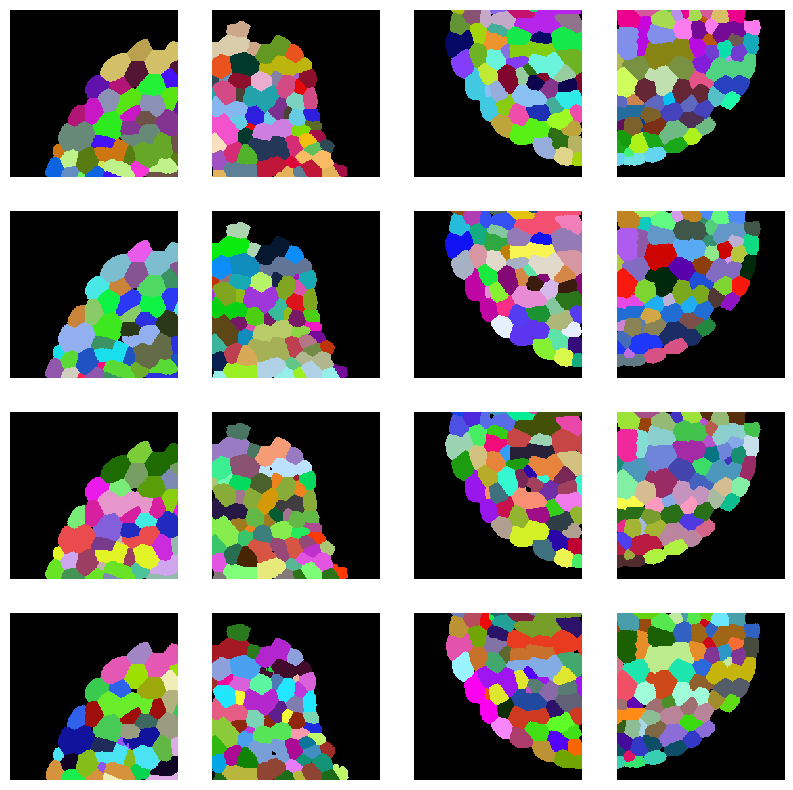

In [23]:
_, axs = plt.subplots(4, 4, figsize=(10, 10))
axs = axs.ravel()
for i in range(len(axs)):
    axs[i].imshow(gt[i].numpy().squeeze(), cmap=get_random_colors(gt[i]), interpolation='none')
    axs[i].axis('off')
plt.show()